# 05 — Değerlendirme
Test seti üzerinde inference, per-class threshold optimizasyonu, baseline vs scratch karşılaştırması.

In [1]:
import pickle
from pathlib import Path

# --- Yerel ---
CODE_ROOT = Path("../")
DATA_ROOT = Path("../")

# --- Colab ---
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_ROOT = Path('/content/drive/MyDrive/film-genre-project')
# DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')
# import sys; sys.path.insert(0, str(CODE_ROOT / 'src'))

import sys
sys.path.insert(0, str(CODE_ROOT / "src"))

POSTERS_DIR      = DATA_ROOT / "posters"
TEST_CSV         = DATA_ROOT / "test.csv"
VAL_CSV          = DATA_ROOT / "val.csv"
MLB_PKL          = DATA_ROOT / "mlb.pkl"
SCRATCH_CKPT     = CODE_ROOT / "checkpoints" / "scratch"  / "best.pt"
BASELINE_CKPT    = CODE_ROOT / "checkpoints" / "baseline" / "best.pt"

with open(MLB_PKL, "rb") as f:
    mlb = pickle.load(f)

N_CLASSES = len(mlb.classes_)
print(f"N_CLASSES={N_CLASSES}  classes={mlb.classes_.tolist()}")

N_CLASSES=15  classes=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller']


In [2]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.metrics import f1_score, hamming_loss

from dataset import PosterDataset
from model import PosterCNN
from eval import find_best_thresholds, evaluate
from transforms import val_transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 1. Test DataLoader

In [3]:
BATCH_SIZE  = 64
NUM_WORKERS = 2

val_ds  = PosterDataset(VAL_CSV,  POSTERS_DIR, mlb, transform=val_transforms)
test_ds = PosterDataset(TEST_CSV, POSTERS_DIR, mlb, transform=val_transforms)

val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Val: {len(val_ds):,}  Test: {len(test_ds):,}")

Val: 1,818  Test: 1,806


## 2. Scratch CNN — threshold optimizasyonu + test metrikleri

In [4]:
scratch_model = PosterCNN(n_classes=N_CLASSES).to(DEVICE)
scratch_model.load_state_dict(torch.load(SCRATCH_CKPT, map_location=DEVICE))
scratch_model.eval()
print("Scratch CNN yüklendi:", SCRATCH_CKPT)

# Val seti üzerinde per-class threshold optimizasyonu
scratch_thresholds = find_best_thresholds(scratch_model, val_loader, DEVICE, N_CLASSES)
print("Optimized thresholds:")
for genre, t in zip(mlb.classes_, scratch_thresholds):
    print(f"  {genre:20s}: {t:.2f}")

Scratch CNN yüklendi: ..\checkpoints\scratch\best.pt
Optimized thresholds:
  Action              : 0.55
  Adventure           : 0.60
  Animation           : 0.50
  Comedy              : 0.30
  Crime               : 0.55
  Documentary         : 0.30
  Drama               : 0.40
  Family              : 0.60
  Fantasy             : 0.45
  History             : 0.40
  Horror              : 0.55
  Mystery             : 0.50
  Romance             : 0.50
  Science Fiction     : 0.50
  Thriller            : 0.60


In [5]:
scratch_metrics = evaluate(scratch_model, test_loader, DEVICE, scratch_thresholds)

print("=== Scratch CNN — Test Metrikleri ===")
print(f"  Macro F1    : {scratch_metrics['macro_f1']:.4f}")
print(f"  Micro F1    : {scratch_metrics['micro_f1']:.4f}")
print(f"  Hamming Loss: {scratch_metrics['hamming_loss']:.4f}")
print("\nPer-class F1:")
for genre, f1 in zip(mlb.classes_, scratch_metrics["per_class_f1"]):
    print(f"  {genre:20s}: {f1:.4f}")

=== Scratch CNN — Test Metrikleri ===
  Macro F1    : 0.3327
  Micro F1    : 0.3900
  Hamming Loss: 0.3362

Per-class F1:
  Action              : 0.3701
  Adventure           : 0.2462
  Animation           : 0.3188
  Comedy              : 0.6242
  Crime               : 0.2986
  Documentary         : 0.1142
  Drama               : 0.6292
  Family              : 0.3989
  Fantasy             : 0.2345
  History             : 0.1008
  Horror              : 0.3708
  Mystery             : 0.1782
  Romance             : 0.3557
  Science Fiction     : 0.2933
  Thriller            : 0.4571


## 3. Baseline — threshold optimizasyonu + test metrikleri

In [6]:
weights = torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
baseline_model = torchvision.models.mobilenet_v3_small(weights=None)
in_features = baseline_model.classifier[-1].in_features
baseline_model.classifier[-1] = nn.Linear(in_features, N_CLASSES)
baseline_model.load_state_dict(torch.load(BASELINE_CKPT, map_location=DEVICE))
baseline_model = baseline_model.to(DEVICE)
baseline_model.eval()
print("Baseline yüklendi:", BASELINE_CKPT)

baseline_thresholds = find_best_thresholds(baseline_model, val_loader, DEVICE, N_CLASSES)
baseline_metrics    = evaluate(baseline_model, test_loader, DEVICE, baseline_thresholds)

print("=== Baseline — Test Metrikleri ===")
print(f"  Macro F1    : {baseline_metrics['macro_f1']:.4f}")
print(f"  Micro F1    : {baseline_metrics['micro_f1']:.4f}")
print(f"  Hamming Loss: {baseline_metrics['hamming_loss']:.4f}")

Baseline yüklendi: ..\checkpoints\baseline\best.pt
=== Baseline — Test Metrikleri ===
  Macro F1    : 0.3832
  Micro F1    : 0.4737
  Hamming Loss: 0.1829


## 4. Karşılaştırma grafiği

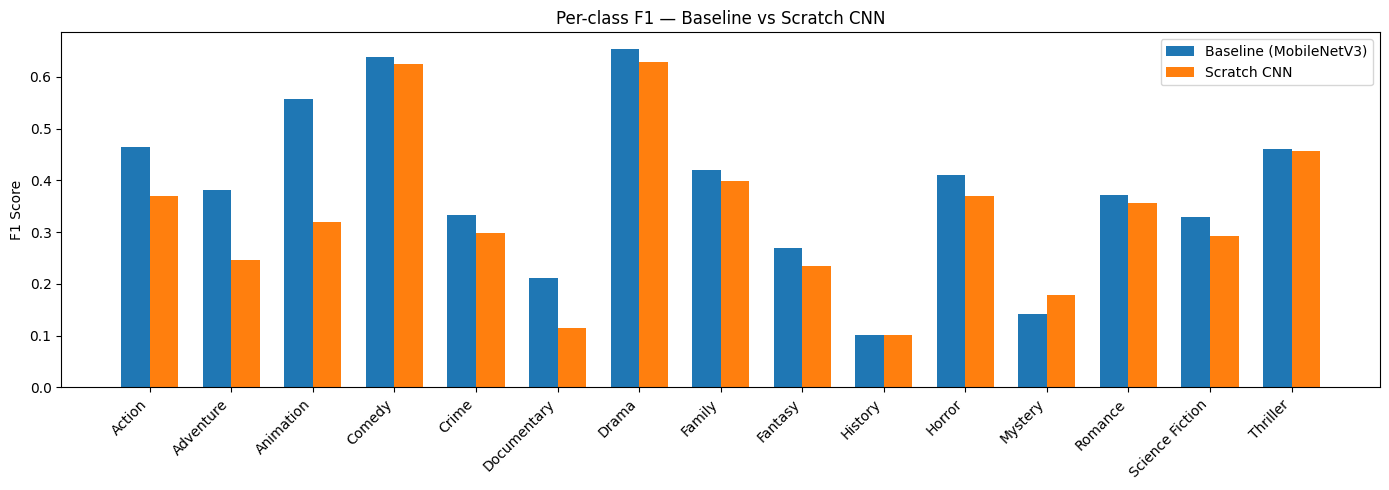


Scratch / Baseline oranı: 86.8%
BASARILI — Scratch CNN baseline'ın %60'ına veya üstüne ulasti.


In [7]:
genres = list(mlb.classes_)
x = np.arange(len(genres))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, baseline_metrics["per_class_f1"], w, label="Baseline (MobileNetV3)")
ax.bar(x + w/2, scratch_metrics["per_class_f1"],  w, label="Scratch CNN")
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1 — Baseline vs Scratch CNN")
ax.legend()
plt.tight_layout()
plt.show()

ratio = scratch_metrics["macro_f1"] / (baseline_metrics["macro_f1"] + 1e-9)
print(f"\nScratch / Baseline oranı: {ratio:.1%}")
if ratio >= 0.60:
    print("BASARILI — Scratch CNN baseline'ın %60'ına veya üstüne ulasti.")
else:
    print("Henuz hedefe ulasilmadi. Daha fazla epoch veya Focal Loss dene.")

## 5. Görsel örnekler — tahmin vs gerçek

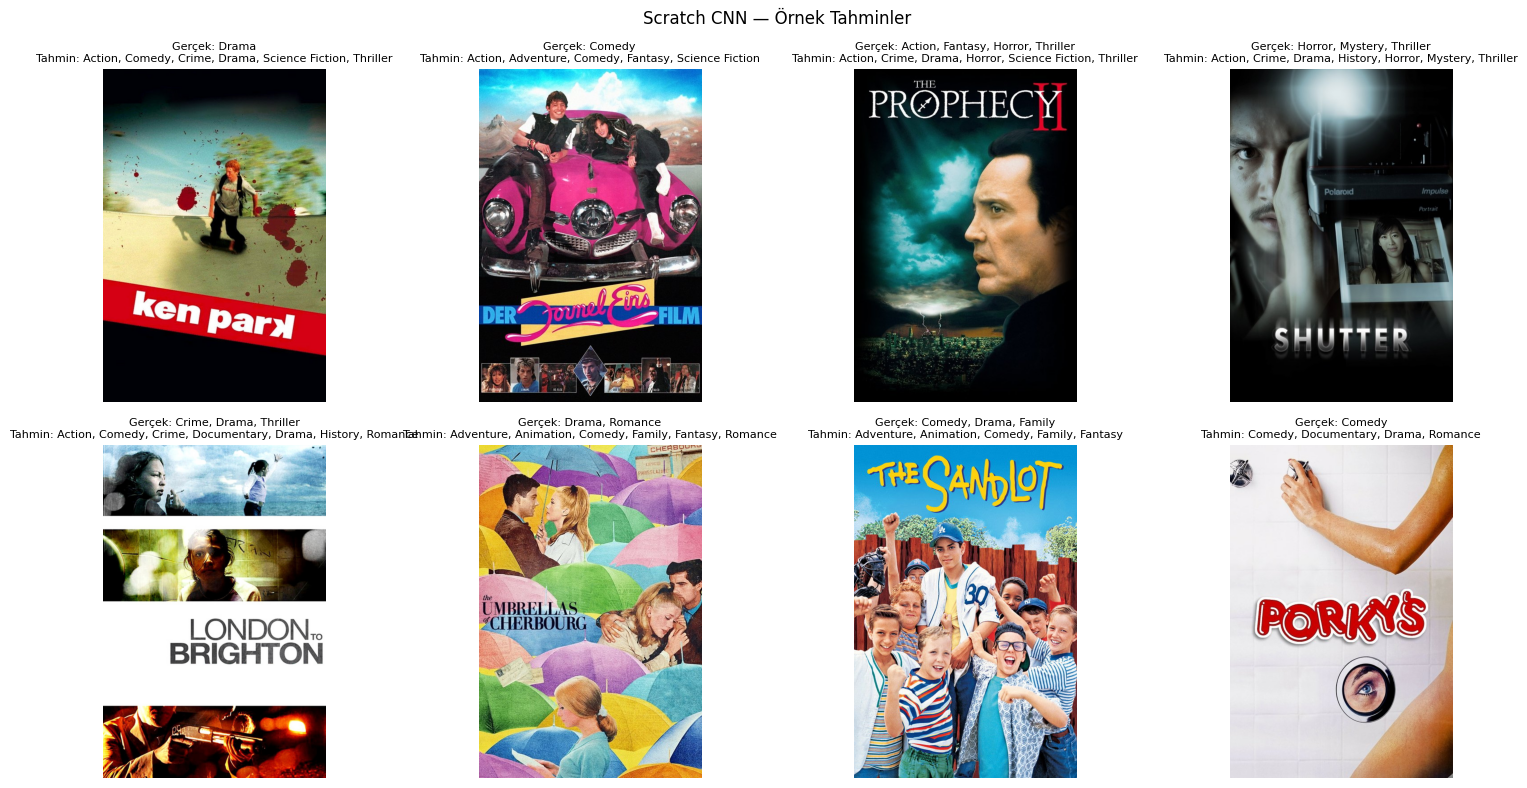

In [12]:
import pandas as pd

test_df = pd.read_csv(TEST_CSV, dtype={"tmdb_id": str})

scratch_model.eval()
sample_indices = np.random.choice(len(test_ds), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flat, sample_indices):
    tmdb_id = test_df.iloc[idx]["tmdb_id"]
    img_pil = Image.open(POSTERS_DIR / f"{tmdb_id}.jpg").convert("RGB")

    img_tensor, true_label = test_ds[idx]
    with torch.no_grad():
        logits = scratch_model(img_tensor.unsqueeze(0).to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()[0]

    pred_labels = [g for g, p, t in zip(mlb.classes_, probs, scratch_thresholds) if p > t]
    true_labels = [g for g, v in zip(mlb.classes_, true_label) if v > 0.5]

    ax.imshow(img_pil)
    ax.set_title(
        f"Gerçek: {', '.join(true_labels)}\n"
        f"Tahmin: {', '.join(pred_labels) or '-'}",
        fontsize=8,
    )
    ax.axis("off")

plt.suptitle("Scratch CNN — Örnek Tahminler", fontsize=12)
plt.tight_layout()
plt.show()